# Pipeline Diagram – Component Visualizations

Publication-ready inset graphics for the PLATE-VS pipeline diagram.

Generated figures (saved as SVG + PNG + PDF):
1. **Activity filtering funnel** (ChEMBL → cleaned activities)
2. **Target clustering network** (UniProt targets coloured by community)
3. **Per-target active count distribution** (log-scale histogram)
4. **Ligand novelty / Tanimoto similarity** (distance to co-crystal)
5. **Decoy property overlap mini-CDFs** (MW & LogP)
6. **Final dataset composition** (donut chart)

In [22]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
from pathlib import Path
from tqdm import tqdm

# RDKit for property calculation
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

DATA_DIR   = Path('../data')
OUTPUT_DIR = Path('../data/output/figures/diagram_components')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':  'DejaVu Sans',
    'font.weight':  'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth': 1.8,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

PALETTE = {
    'structure': '#4A90D9',
    'activity':  '#27AE60',
    'cluster':   '#8E44AD',
    'decoy':     '#E74C3C',
    'final':     '#F39C12',
}

def save_fig(fig, name, dpi=300):
    for fmt in ('svg', 'png', 'pdf'):
        fig.savefig(OUTPUT_DIR / f'{name}.{fmt}', format=fmt,
                    dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved  {name}  →  {OUTPUT_DIR}')

## Figure 1 – Activity Filtering Funnel

Saved  fig1_activity_funnel  →  ../data/output/figures/diagram_components


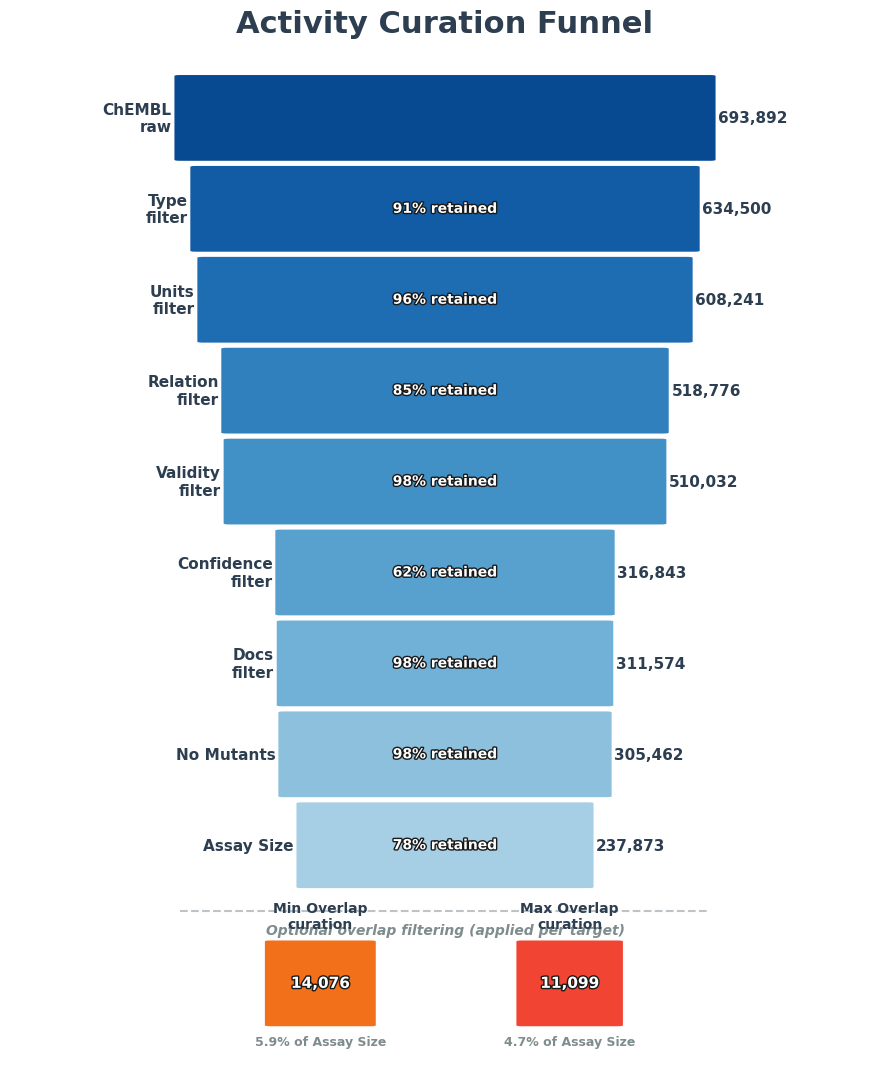

In [23]:
# Exact counts from statistics_visualization_svg notebook
stages_base = [
    ('ChEMBL\nraw',        693_892),
    ('Type\nfilter',       634_500),
    ('Units\nfilter',      608_241),
    ('Relation\nfilter',   518_776),
    ('Validity\nfilter',   510_032),
    ('Confidence\nfilter', 316_843),
    ('Docs\nfilter',       311_574),
    ('No Mutants',          305_462),
    ('Assay Size',          237_873),
]
stages_overlap = [
    ('Min Overlap\ncuration',  14_076),
    ('Max Overlap\ncuration',  11_099),
]

labels = [s[0] for s in stages_base]
values = [s[1] for s in stages_base]
n      = len(stages_base)

bar_h  = 0.72
gap    = 0.05
y_step = bar_h + gap
total_h = n * y_step
max_w  = 1.0
min_w  = 0.30

fig, ax = plt.subplots(figsize=(9, 11), facecolor='white')
ax.set_facecolor('white')
ax.axis('off')

cmap   = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * (1 - i / (n - 1))) for i in range(n)]

# ── Main funnel bars ──────────────────────────────────────────────────────────
for i, (label, val) in enumerate(zip(labels, values)):
    frac  = val / values[0]
    width = min_w + (max_w - min_w) * frac
    x0    = (max_w - width) / 2
    y0    = total_h - (i + 1) * y_step

    rect = mpatches.FancyBboxPatch(
        (x0, y0), width, bar_h,
        boxstyle='round,pad=0.012',
        facecolor=colors[i], edgecolor='white', linewidth=1.5, zorder=3)
    ax.add_patch(rect)

    ax.text(x0 - 0.015, y0 + bar_h / 2, label,
            ha='right', va='center', fontsize=11, fontweight='bold', color='#2C3E50')
    ax.text(x0 + width + 0.015, y0 + bar_h / 2, f'{val:,}',
            ha='left', va='center', fontsize=11, fontweight='bold', color='#2C3E50')

    if i > 0:
        pct = 100 * val / values[i - 1]
        ax.text(x0 + width / 2, y0 + bar_h / 2,
                f'{pct:.0f}% retained',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white',
                path_effects=[pe.withStroke(linewidth=2, foreground='#1a1a1a')])

# ── Dashed divider + label ────────────────────────────────────────────────────
last_y = total_h - n * y_step
divider_y = last_y - 0.35
ax.plot([0, max_w], [divider_y + 0.15, divider_y + 0.15],
        color='#BDC3C7', linewidth=1.5, linestyle='--', zorder=2)
ax.text(max_w / 2, divider_y + 0.05,
        'Optional overlap filtering (applied per target)',
        ha='center', va='top', fontsize=10, color='#7F8C8D', style='italic')

# ── Overlap branch bars (side by side) ───────────────────────────────────────
branch_colors = [plt.cm.Oranges(0.60), plt.cm.Reds(0.60)]
n_ov = len(stages_overlap)
branch_w = (max_w - 0.06) / n_ov
branch_y0 = divider_y - y_step - 0.05

for j, (label, val) in enumerate(stages_overlap):
    frac  = val / values[0]
    width = min_w * 0.5 + (branch_w - min_w * 0.5) * frac * 6  # scale up for visibility
    width = min(width, branch_w - 0.04)
    x0    = 0.03 + j * branch_w + (branch_w - width) / 2
    y0    = branch_y0

    rect = mpatches.FancyBboxPatch(
        (x0, y0), width, bar_h,
        boxstyle='round,pad=0.012',
        facecolor=branch_colors[j], edgecolor='white', linewidth=1.5, zorder=3)
    ax.add_patch(rect)

    ax.text(x0 + width / 2, y0 + bar_h + 0.08, label,
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2C3E50')
    ax.text(x0 + width / 2, y0 + bar_h / 2, f'{val:,}',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white',
            path_effects=[pe.withStroke(linewidth=2, foreground='#1a1a1a')])
    pct = 100 * val / values[-1]
    ax.text(x0 + width / 2, y0 - 0.08, f'{pct:.1f}% of Assay Size',
            ha='center', va='top', fontsize=9, color='#7F8C8D')

ax.set_xlim(-0.32, 1.32)
ax.set_ylim(branch_y0 - 0.45, total_h + 0.2)
ax.set_title('Activity Curation Funnel', fontsize=22, fontweight='bold',
             color='#2C3E50', pad=10)

fig.tight_layout()
save_fig(fig, 'fig1_activity_funnel')
plt.show()

In [ ]:
# Figure 1.1 - Activity Filtering Funnel (seaborn barplot, total activities)
import seaborn as sns

# Total activity datapoint counts (from statistics_visualization_svg notebook)
stages_base_act = [
    ('ChEMBL\nraw',        1_237_090),
    ('Type\nfilter',       1_051_008),
    ('Units\nfilter',        983_284),
    ('Relation\nfilter',     749_185),
    ('Validity\nfilter',     733_391),
    ('Confidence\nfilter',   420_967),
    ('Docs\nfilter',         415_109),
    ('No Mutants',           405_562),
    ('Assay Size',           333_748),
]
stages_overlap_act = [
    ('Min Overlap\ncuration',  63_589),
    ('Max Overlap\ncuration',  45_379),
]

# Build colors: Blues gradient for base stages, Orange/Red for overlap stages
cmap_blues = plt.cm.Blues
n = len(stages_base_act)
base_colors    = [cmap_blues(0.35 + 0.55 * (1 - i / (n - 1))) for i in range(n)]
overlap_colors = [plt.cm.Oranges(0.60), plt.cm.Reds(0.60)]

all_stages = stages_base_act + stages_overlap_act
all_labels = [s[0].replace('\n', ' ') for s in all_stages]
all_values = [s[1] for s in all_stages]
all_colors = base_colors + overlap_colors

df_funnel = pd.DataFrame({'Stage': all_labels, 'Count': all_values})

fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
ax.set_facecolor('white')
sns.barplot(data=df_funnel, y='Stage', x='Count', palette=all_colors, orient='h', ax=ax)

# Annotate bar ends with counts — no bold
for patch, val in zip(ax.patches, all_values):
    ax.text(
        patch.get_width() + max(all_values) * 0.005,
        patch.get_y() + patch.get_height() / 2,
        f'{val:,}',
        ha='left', va='center', fontsize=9, fontweight='normal', color='#2C3E50',
    )

ax.set_ylabel('Filtering Stage', fontsize=12, fontweight='normal')
ax.set_xlabel('Number of Activities', fontsize=12, fontweight='normal')

# Ensure tick labels are not bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')

# Extend x-axis so right-side labels are not clipped
ax.set_xlim(0, max(all_values) * 1.18)

fig.tight_layout()
save_fig(fig, 'fig1_1_activity_funnel_barplot')
plt.show()

In [ ]:
# Figure 1.2 - Activity Filtering Funnel (log scale)
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
ax.set_facecolor('white')
sns.barplot(data=df_funnel, y='Stage', x='Count', palette=all_colors, orient='h', ax=ax)

ax.set_xscale('log')

# Annotate bar ends with counts
for patch, val in zip(ax.patches, all_values):
    ax.text(
        patch.get_width() * 1.03,
        patch.get_y() + patch.get_height() / 2,
        f'{val:,}',
        ha='left', va='center', fontsize=9, fontweight='normal', color='#2C3E50',
    )

ax.set_ylabel('Filtering Stage', fontsize=12, fontweight='normal')
ax.set_xlabel('Number of Activities (log scale)', fontsize=12, fontweight='normal')

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')

# Leave a bit of room on the right for count labels
ax.set_xlim(left=ax.get_xlim()[0])

fig.tight_layout()
save_fig(fig, 'fig1_2_activity_funnel_barplot_log')
plt.show()

## Figure 2 – Target Clustering Network

Saved  fig2_target_clustering  →  ../data/output/figures/diagram_components


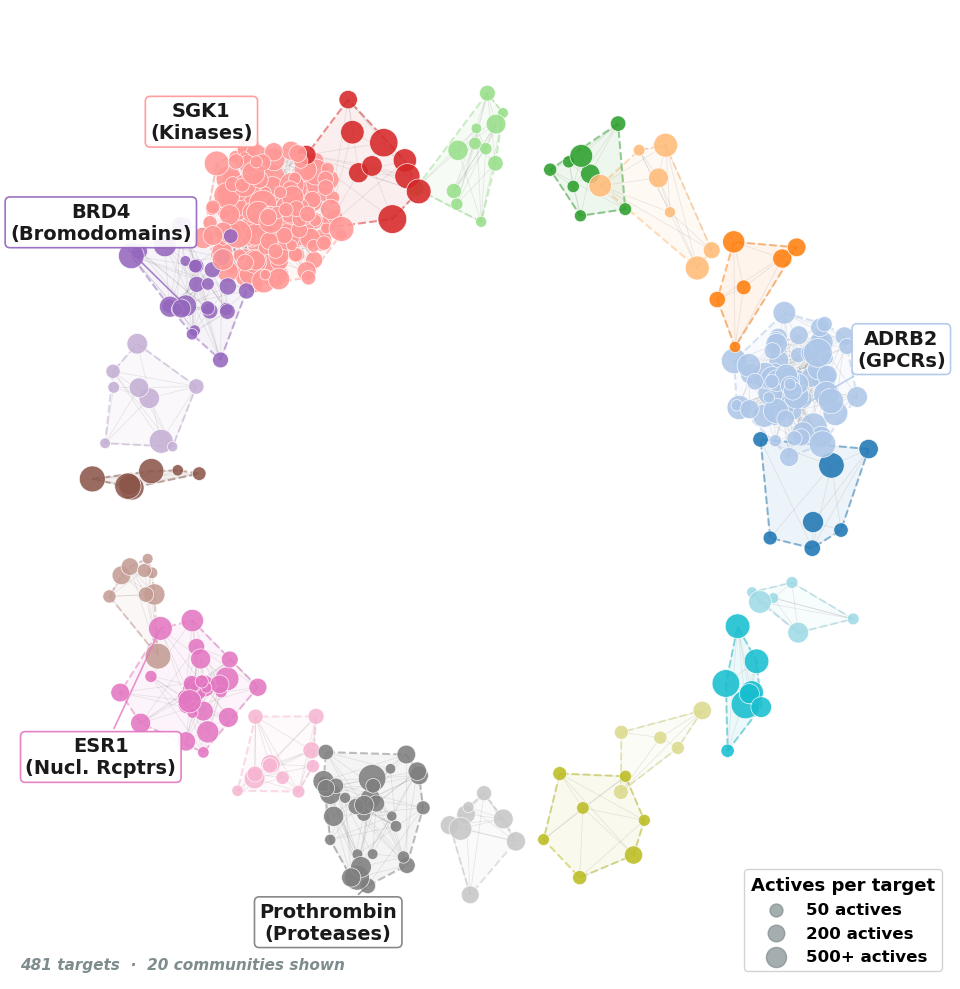

In [55]:
import networkx as nx
from matplotlib.colors import to_rgba
from collections import Counter

# ── Load data ─────────────────────────────────────────────────────────────────
cluster_df  = pd.read_csv(DATA_DIR / 'uniprot_bipartite_cluster_labels.csv')
affinity_df = pd.read_parquet(DATA_DIR / 'filtered_chembl_affinity.parquet',
                               columns=['source_uniprot_id'])

n_actives = affinity_df['source_uniprot_id'].value_counts().rename('n_actives')
cluster_df = cluster_df.merge(n_actives.reset_index().rename(
    columns={'source_uniprot_id': 'uniprot'}), on='uniprot', how='left')
cluster_df['n_actives'] = cluster_df['n_actives'].fillna(0).astype(int)

# Use qcov=50 clusters; keep top-N clusters by size for readability
col  = 'cluster_bipartite_qcov_50'
top_clusters = cluster_df[col].value_counts().head(20).index
sub  = cluster_df[cluster_df[col].isin(top_clusters)].copy()

# ── Representative labels for large clusters (one per cluster) ────────────────
# Maps cluster_id → (uniprot_id, short display name)
CLUSTER_REPS = {
    128: ('O00141',  'SGK1\n(Kinases)'),
     63: ('P07550',  'ADRB2\n(GPCRs)'),
    170: ('P00734',  'Prothrombin\n(Proteases)'),
    152: ('P03372',  'ESR1\n(Nucl. Rcptrs)'),
    131: ('O60885',  'BRD4\n(Bromodomains)'),
}

# ── Build graph ───────────────────────────────────────────────────────────────
G = nx.Graph()
for _, row in sub.iterrows():
    G.add_node(row['uniprot'],
               cluster=row[col],
               n_actives=row['n_actives'])

for cl_id, grp in sub.groupby(col):
    members = grp['uniprot'].tolist()
    for i in range(len(members)):
        for j in range(i + 1, min(i + 4, len(members))):
            G.add_edge(members[i], members[j])

# ── Layout ────────────────────────────────────────────────────────────────────
communities = {n: G.nodes[n]['cluster'] for n in G.nodes}
unique_cl   = sorted(set(communities.values()))
n_cl        = len(unique_cl)

import math
centres = {cl: (math.cos(2*math.pi*i/n_cl) * 2.5,
                math.sin(2*math.pi*i/n_cl) * 2.5)
           for i, cl in enumerate(unique_cl)}

pos = {}
rng = np.random.default_rng(42)
for cl in unique_cl:
    members = [n for n in G.nodes if communities[n] == cl]
    cx, cy  = centres[cl]
    for m in members:
        angle  = rng.uniform(0, 2 * math.pi)
        radius = rng.uniform(0, 0.55)
        pos[m] = (cx + radius * math.cos(angle),
                  cy + radius * math.sin(angle))

# ── Colors & sizes ────────────────────────────────────────────────────────────
cmap_net  = plt.cm.tab20
cl_color  = {cl: cmap_net(i / n_cl) for i, cl in enumerate(unique_cl)}
node_colors = [cl_color[communities[n]] for n in G.nodes]

sizes_raw = np.array([G.nodes[n]['n_actives'] for n in G.nodes], dtype=float)
sizes_raw = np.where(sizes_raw == 0, 5, sizes_raw)
node_sizes = 30 + 400 * (sizes_raw / sizes_raw.max()) ** 0.5

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')
ax.set_facecolor('#F8F9FA')
ax.set_aspect('equal')
ax.axis('off')

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.6, edge_color='#555')
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes,
                       alpha=0.88, linewidths=0.5, edgecolors='white')

# Community convex-hull shading
for cl in unique_cl:
    members = [n for n in G.nodes if communities[n] == cl]
    if len(members) < 3:
        continue
    pts = np.array([pos[m] for m in members])
    from scipy.spatial import ConvexHull
    try:
        hull = ConvexHull(pts)
        hull_pts = pts[hull.vertices]
        patch = plt.Polygon(hull_pts, closed=True,
                            facecolor=(*cl_color[cl][:3], 0.08),
                            edgecolor=(*cl_color[cl][:3], 0.5),
                            linewidth=1.5, linestyle='--', zorder=0)
        ax.add_patch(patch)
    except Exception:
        pass

# ── Annotate one representative node per large cluster ───────────────────────
# Position the text slightly outside the cluster centre, with a leader line
for cl_id, (uniprot, label) in CLUSTER_REPS.items():
    if cl_id not in top_clusters or uniprot not in pos:
        continue
    nx_pos, ny_pos = pos[uniprot]
    cx, cy = centres[cl_id]
    # Offset text toward cluster periphery (away from canvas centre)
    dx = cx - 0.0
    dy = cy - 0.0
    norm = math.hypot(dx, dy) or 1
    tx = cx + (dx / norm) * 0.85
    ty = cy + (dy / norm) * 0.85
    ec = cl_color[cl_id]
    ax.annotate(
        label,
        xy=(nx_pos, ny_pos),
        xytext=(tx, ty),
        fontsize=14,
        color='#1a1a1a',
        ha='center', va='center',
        arrowprops=dict(arrowstyle='-', color=ec, lw=1.2, alpha=0.8),
        bbox=dict(facecolor='white', edgecolor=ec, linewidth=1.2,
                  boxstyle='round,pad=0.25', alpha=0.92),
        zorder=5,
    )

# ax.set_title('Target Clustering\n(Pocket Communities, qcov \u2265 50%)',
#              fontsize=20, fontweight='bold', color='#2C3E50', pad=10)

for n_act, label in [(50, '50'), (200, '200'), (500, '500+')]:
    s = 30 + 400 * (min(n_act, sizes_raw.max()) / sizes_raw.max()) ** 0.5
    ax.scatter([], [], s=s, c='#7F8C8D', alpha=0.7, label=f'{label} actives')
ax.legend(title='Actives per target', title_fontsize=13,
          fontsize=12, loc='lower right', framealpha=0.85)

ax.text(0.01, 0.01, f'{G.number_of_nodes()} targets  \u00b7  {n_cl} communities shown',
        transform=ax.transAxes, fontsize=11, color='#7F8C8D', style='italic')

fig.tight_layout()
save_fig(fig, 'fig2_target_clustering')
plt.show()

## Figure 3 – Per-target Active Count Distribution

Saved  fig3_active_count_distribution  →  ../data/output/figures/diagram_components


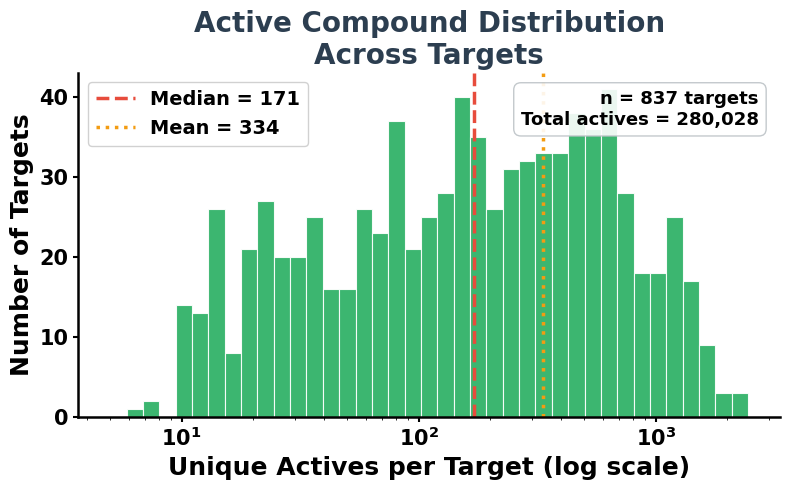

In [25]:
affinity_df = pd.read_parquet(DATA_DIR / 'filtered_chembl_affinity.parquet',
                               columns=['source_uniprot_id', 'InchiKey'])

counts = (affinity_df.groupby('source_uniprot_id')['InchiKey']
          .nunique().sort_values(ascending=False).reset_index())
counts.columns = ['uniprot', 'n_actives']

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

vals = counts['n_actives'].values
bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 40)

ax.hist(vals, bins=bins, color=PALETTE['activity'],
        edgecolor='white', linewidth=0.8, alpha=0.9)
ax.set_xscale('log')

ax.axvline(np.median(vals), color='#E74C3C', linewidth=2.5,
           linestyle='--', label=f'Median = {int(np.median(vals)):,}')
ax.axvline(np.mean(vals),   color='#F39C12', linewidth=2.5,
           linestyle=':',  label=f'Mean = {int(np.mean(vals)):,}')

ax.set_xlabel('Unique Actives per Target (log scale)', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Targets',                     fontsize=18, fontweight='bold')
ax.set_title('Active Compound Distribution\nAcross Targets',
             fontsize=20, fontweight='bold', color='#2C3E50')
ax.tick_params(labelsize=15)
ax.legend(fontsize=14, framealpha=0.9)

ax.text(0.97, 0.95,
        f'n = {len(counts):,} targets\nTotal actives = {vals.sum():,}',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#BDC3C7', alpha=0.9))

fig.tight_layout()
save_fig(fig, 'fig3_active_count_distribution')
plt.show()

## Figure 4 – Ligand Novelty (Tanimoto Distance to Co-crystal)

In [26]:
# Load train similarity scores (distance to nearest co-crystal ligand)
sim_path = DATA_DIR / 'train_similarity_scores.parquet'
sim_df   = pd.read_parquet(sim_path)
print(sim_df.columns.tolist())
print(sim_df.head(2))

['query_system', 'target_system', 'pli_qcov', 'pli_unique_qcov', 'pocket_fident', 'pocket_fident_qcov', 'pocket_lddt', 'pocket_lddt_qcov', 'pocket_qcov', 'protein_fident_max', 'protein_fident_qcov_max', 'protein_fident_qcov_weighted_max', 'protein_fident_qcov_weighted_sum', 'protein_fident_weighted_max', 'protein_fident_weighted_sum', 'protein_lddt_max', 'protein_lddt_qcov_max', 'protein_lddt_qcov_weighted_max', 'protein_lddt_qcov_weighted_sum', 'protein_lddt_weighted_max', 'protein_lddt_weighted_sum', 'protein_qcov_max', 'protein_qcov_weighted_max', 'protein_qcov_weighted_sum', 'protein_seqsim_max', 'protein_seqsim_qcov_max', 'protein_seqsim_qcov_weighted_max', 'protein_seqsim_qcov_weighted_sum', 'protein_seqsim_weighted_max', 'protein_seqsim_weighted_sum', 'query_ligand_instance_chain', 'color', 'shape', 'sucos_protein', 'sucos_shape', 'tanimoto', 'sucos_protein_pocket_qcov', 'sucos_protein_pocket_lddt_qcov', 'sucos_shape_pocket_qcov', 'sucos_shape_pocket_lddt_qcov', 'shape_pocket_qc

Using column: tanimoto
Saved  fig4_ligand_novelty  →  ../data/output/figures/diagram_components


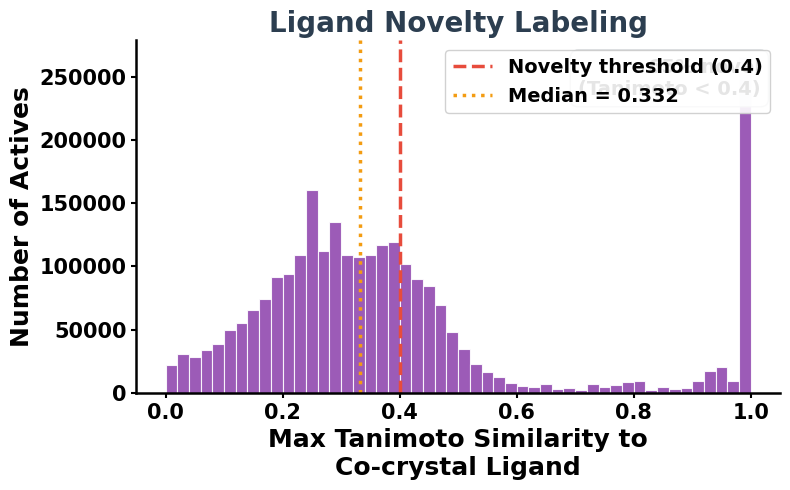

In [27]:
# Adapt column name based on output above
# Common candidates: 'tanimoto', 'max_tanimoto', 'similarity', 'distance'
tanimoto_col = [c for c in sim_df.columns
                if 'tanimoto' in c.lower() or 'simil' in c.lower()][0]
print('Using column:', tanimoto_col)

vals_sim = sim_df[tanimoto_col].dropna().values

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

ax.hist(vals_sim, bins=50, color=PALETTE['cluster'],
        edgecolor='white', linewidth=0.8, alpha=0.88)

ax.axvline(0.4, color='#E74C3C', linewidth=2.5, linestyle='--',
           label='Novelty threshold (0.4)')
ax.axvline(np.median(vals_sim), color='#F39C12', linewidth=2.5, linestyle=':',
           label=f'Median = {np.median(vals_sim):.3f}')

ax.set_xlabel('Max Tanimoto Similarity to\nCo-crystal Ligand', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Actives',                              fontsize=18, fontweight='bold')
ax.set_title('Ligand Novelty Labeling',
             fontsize=20, fontweight='bold', color='#2C3E50')
ax.tick_params(labelsize=15)
ax.legend(fontsize=14, framealpha=0.9)

novel_pct = 100 * (vals_sim < 0.4).mean()
ax.text(0.97, 0.95,
        f'{novel_pct:.0f}% novel\n(Tanimoto < 0.4)',
        transform=ax.transAxes, fontsize=14, fontweight='bold',
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#BDC3C7', alpha=0.9))

fig.tight_layout()
save_fig(fig, 'fig4_ligand_novelty')
plt.show()

## Figure 5 – Decoy vs Active Property CDFs (MW & LogP)

In [28]:
# Load a representative target with both actives and decoys
import glob, random

decoy_files = sorted(glob.glob(str(DATA_DIR / 'chembl_affinity/uniprot_*/deepcoy_output/*_generated_decoys.txt')))
active_files = sorted(glob.glob(str(DATA_DIR / 'chembl_affinity/uniprot_*/*_chembl_activities_filtered.parquet')))

# Pick target with most decoys
def count_lines(f):
    try:
        with open(f) as fh:
            return sum(1 for _ in fh)
    except:
        return 0

# Use a known large target; fall back to biggest available
target_id = 'O14684'
decoy_path  = DATA_DIR / f'chembl_affinity/uniprot_{target_id}/deepcoy_output/{target_id}_generated_decoys.txt'
active_path = DATA_DIR / f'chembl_affinity/uniprot_{target_id}/{target_id}_chembl_activities_filtered.parquet'

if not decoy_path.exists():
    decoy_path  = Path(random.choice(decoy_files))
    active_path = Path(decoy_path.parent.parent / (decoy_path.stem.replace('_generated_decoys',
                        '_chembl_activities_filtered') + '.parquet'))

print('Target:', decoy_path.parent.name)

df_decoys  = pd.read_csv(decoy_path, sep=' ', header=None,
                         names=['active_smiles', 'decoy_smiles'])
df_actives = pd.read_parquet(active_path)

def calc_props(smiles_series, label):
    rows = []
    for smi in smiles_series.dropna().sample(min(500, len(smiles_series)), random_state=42):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            rows.append({'MW': Descriptors.MolWt(mol),
                         'LogP': Descriptors.MolLogP(mol),
                         'Type': label})
    return pd.DataFrame(rows)

act_smi = (df_actives['canonical_smiles'] if 'canonical_smiles' in df_actives.columns
           else df_actives.iloc[:, 0])
df_a = calc_props(act_smi,            'Active')
df_d = calc_props(df_decoys['decoy_smiles'], 'Decoy')
df_p = pd.concat([df_a, df_d], ignore_index=True)
print(df_p['Type'].value_counts())

Target: deepcoy_output
Type
Active    500
Decoy     500
Name: count, dtype: int64


Saved  fig5_decoy_cdf  →  ../data/output/figures/diagram_components


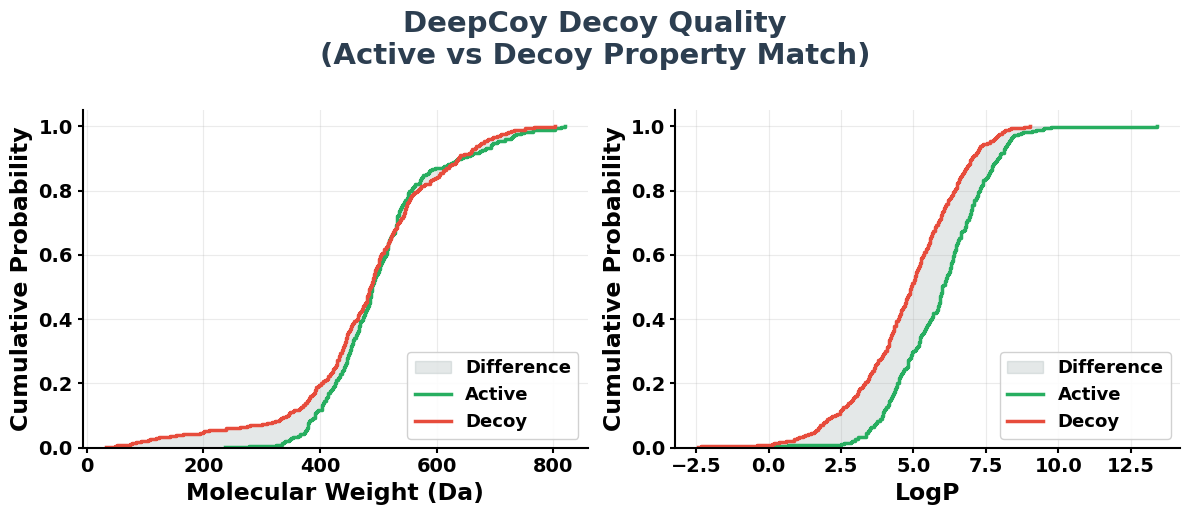

In [ ]:
ACTIVE_COLOR = '#27AE60'
DECOY_COLOR  = '#E74C3C'
DIFF_COLOR   = '#95A5A6'

props   = ['MW', 'LogP']
xlabels = ['Molecular Weight (Da)', 'LogP']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

for ax, prop, xlabel in zip(axes, props, xlabels):
    act = np.sort(df_p[df_p['Type'] == 'Active'][prop].dropna())
    dec = np.sort(df_p[df_p['Type'] == 'Decoy'][prop].dropna())

    act_cdf = np.arange(1, len(act) + 1) / len(act)
    dec_cdf = np.arange(1, len(dec) + 1) / len(dec)

    all_v = np.sort(np.concatenate([act, dec]))
    c1 = np.searchsorted(act, all_v, 'right') / len(act)
    c2 = np.searchsorted(dec, all_v, 'right') / len(dec)

    ax.fill_between(all_v, c1, c2, alpha=0.25, color=DIFF_COLOR, label='Difference')
    ax.step(act, act_cdf, where='post', color=ACTIVE_COLOR, linewidth=2.5, label='Active')
    ax.step(dec, dec_cdf, where='post', color=DECOY_COLOR,  linewidth=2.5, label='Decoy')

    # CDF overlap coefficient
    ov = 1 - 0.5 * np.trapz(np.abs(c1 - c2), all_v) / (all_v[-1] - all_v[0])

    ax.set_title(f'{prop}  |  Overlap: {ov:.3f}', fontsize=19, fontweight='bold')
    ax.set_xlabel(xlabel,               fontsize=17, fontweight='bold')
    ax.set_ylabel('Cumulative Probability', fontsize=17, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=13, framealpha=0.9, loc='lower right')
    ax.grid(True, alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    for sp in ax.spines.values():
        sp.set_linewidth(1.5)

# fig.suptitle('DeepCoy Decoy Quality\n(Active vs Decoy Property Match)',
#              fontsize=21, fontweight='bold', color='#2C3E50', y=1.02)
fig.tight_layout()
save_fig(fig, 'fig5_decoy_cdf')
plt.show()

## Figure 6 – Final Dataset Composition (Donut)

In [ ]:
# Load final dataset stats
# minoverlap parquet is a paired file: columns are source_uniprot_id_1 / _2
overlap_df = pd.read_parquet(DATA_DIR / 'minoverlap_chembl_affinity.parquet',
                              columns=['source_uniprot_id_1', 'InchiKey'])

n_targets = overlap_df['source_uniprot_id_1'].nunique()
n_actives = overlap_df['InchiKey'].nunique()

# Estimate decoys: 100 per active (DeepCoy default)
n_decoys = n_actives * 100

labels = [f'{n_targets:,}\nTargets',
          f'{n_actives:,}\nActives',
          f'~{n_decoys/1e6:.1f}M\nDecoys']
sizes  = [n_targets / 1000, n_actives, n_decoys / 100]  # visual proportions
colors = [PALETTE['structure'], PALETTE['activity'], PALETTE['decoy']]

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
ax.set_facecolor('white')
ax.axis('equal')

wedges, texts = ax.pie(
    sizes, labels=None, colors=colors,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.48, edgecolor='white', linewidth=3),
)

# Custom labels outside
for wedge, label, color in zip(wedges, labels, colors):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 1.28 * np.cos(np.deg2rad(angle))
    y = 1.28 * np.sin(np.deg2rad(angle))
    ax.text(x, y, label, ha='center', va='center',
            fontsize=16, fontweight='bold', color=color)

ax.text(0, 0, 'PLATE-VS', ha='center', va='center',
        fontsize=20, fontweight='bold', color='#2C3E50')

ax.set_title('Final Dataset Composition',
             fontsize=21, fontweight='bold', color='#2C3E50', pad=12)

fig.tight_layout()
save_fig(fig, 'fig6_dataset_composition')
plt.show()

## Figure 7 – Chemical Space Network (Active vs Decoys)

Chosen actives (MW): [347, 381, 505]
Nodes: 13  ({'Decoy': 10, 'Active': 3})


[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator
[21:10:56] DEPRECATION WARNING: please use MorganGenerator


Saved  fig7_csn_O14684  →  ../data/output/figures/diagram_components


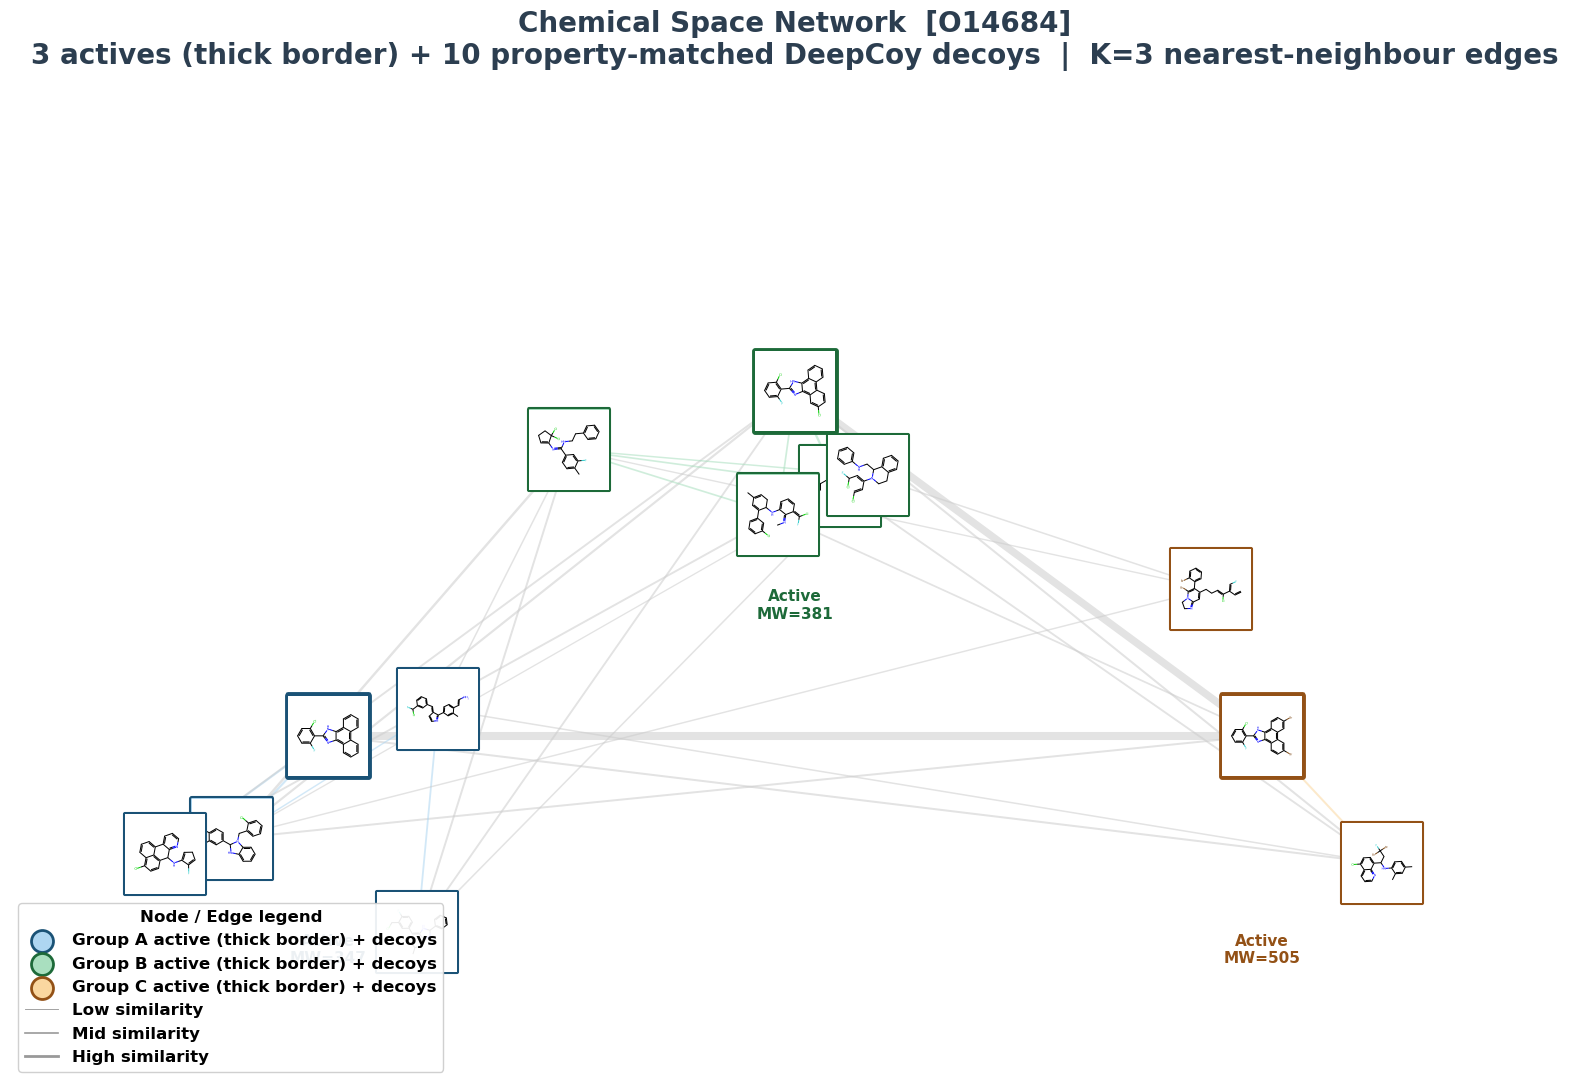

In [20]:
# ── Chemical Space Network: O14684 actives vs DeepCoy decoys ─────────────────
from rdkit import DataStructs
from rdkit.Chem import Draw, AllChem, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

target_id  = 'O14684'
decoy_path  = DATA_DIR / f'chembl_affinity/uniprot_{target_id}/deepcoy_output/{target_id}_generated_decoys.txt'
active_path = DATA_DIR / f'chembl_affinity/uniprot_{target_id}/{target_id}_chembl_activities_filtered.parquet'

df_dec = pd.read_csv(decoy_path, sep=' ', header=None, names=['active_smiles', 'decoy_smiles'])
df_act = pd.read_parquet(active_path, columns=['canonical_smiles'])

# ── Select 3 representative actives (unique, parseable, drug-like) ────────────
def is_valid(smi, mw_lo=200, mw_hi=700):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return False
    mw = Descriptors.MolWt(mol)
    return mw_lo < mw < mw_hi

active_candidates = df_dec['active_smiles'].unique()
valid_actives = [s for s in active_candidates if is_valid(s)][:20]

# Pick 3 with diverse MW
mws = [(s, Descriptors.MolWt(Chem.MolFromSmiles(s))) for s in valid_actives]
mws.sort(key=lambda x: x[1])
idx = [0, len(mws)//2, len(mws)-1]   # low / mid / high MW
chosen_actives = [mws[i][0] for i in idx]
print(f'Chosen actives (MW): {[round(mws[i][1]) for i in idx]}')

# ── Filter effective decoys: property-matched to their active ─────────────────
def get_props(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    return {'MW': Descriptors.MolWt(mol), 'LogP': Descriptors.MolLogP(mol)}

rows = []
GROUP_COLORS = ['#AED6F1', '#A9DFBF', '#FAD7A0']   # blue, green, orange
ACTIVE_EC    = ['#1A5276', '#1D6A39', '#935116']

for g, act_smi in enumerate(chosen_actives):
    act_props = get_props(act_smi)
    if act_props is None: continue
    rows.append({'smiles': act_smi, 'type': 'Active',
                 'group': g, 'MW': act_props['MW'], 'LogP': act_props['LogP']})

    decoys = df_dec[df_dec['active_smiles'] == act_smi]['decoy_smiles'].tolist()
    for dsmi in decoys:
        dp = get_props(dsmi)
        if dp is None: continue
        # Property match filter: MW ±75 Da, LogP ±1.5
        if abs(dp['MW'] - act_props['MW']) < 75 and abs(dp['LogP'] - act_props['LogP']) < 1.5:
            rows.append({'smiles': dsmi, 'type': 'Decoy',
                         'group': g, 'MW': dp['MW'], 'LogP': dp['LogP']})

df_nodes = pd.DataFrame(rows).drop_duplicates('smiles').reset_index(drop=True)
print(f'Nodes: {len(df_nodes)}  ({df_nodes["type"].value_counts().to_dict()})')

# ── Fingerprints & K-NN edges ─────────────────────────────────────────────────
mols = [Chem.MolFromSmiles(s) for s in df_nodes['smiles']]
fps  = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) for m in mols]
n    = len(fps)

sim = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        v = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        sim[i,j] = sim[j,i] = v

# K-NN: each node connects to its top-3 most similar neighbours
K = 3
G = nx.Graph()
for i in range(n):
    G.add_node(i, node_type=df_nodes.loc[i,'type'], group=df_nodes.loc[i,'group'])
for i in range(n):
    top_k = np.argsort(sim[i])[::-1][1:K+1]
    for j in top_k:
        if sim[i,j] > 0.0:
            G.add_edge(i, j, weight=float(sim[i,j]))

# ── Layout: each group forms a cluster around its active ─────────────────────
import math
active_nodes = df_nodes[df_nodes['type']=='Active'].index.tolist()
group_centres = {
    0: np.array([-2.5,  0.0]),
    1: np.array([ 0.0,  2.0]),
    2: np.array([ 2.5,  0.0]),
}
rng = np.random.default_rng(0)
pos = {}
for i, row in df_nodes.iterrows():
    cx, cy = group_centres[row['group']]
    if row['type'] == 'Active':
        pos[i] = np.array([cx, cy])
    else:
        angle  = rng.uniform(0, 2*math.pi)
        radius = rng.uniform(0.6, 1.3)
        pos[i] = np.array([cx + radius*math.cos(angle), cy + radius*math.sin(angle)])

# ── Render mol images ──────────────────────────────────────────────────────────
def mol_to_pil(mol, size=160):
    d = rdMolDraw2D.MolDraw2DCairo(size, size)
    d.drawOptions().addStereoAnnotation = False
    d.drawOptions().padding = 0.12
    d.DrawMolecule(mol)
    d.FinishDrawing()
    return Image.open(BytesIO(d.GetDrawingText())).convert('RGBA')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11), facecolor='white')
ax.set_facecolor('#F7F9FC')
ax.axis('off')

# Edges
for u, v, d in G.edges(data=True):
    xu, yu = pos[u]
    xv, yv = pos[v]
    # Same group → darker
    gu, gv = df_nodes.loc[u,'group'], df_nodes.loc[v,'group']
    color = GROUP_COLORS[gu][:7] if gu == gv else '#CCCCCC'
    ax.plot([xu, xv], [yu, yv], color=color,
            linewidth=d['weight']*8, alpha=0.55, zorder=1, solid_capstyle='round')

# Nodes
ZOOM = 0.36
for i, row in df_nodes.iterrows():
    mol = mols[i]
    if mol is None: continue
    g   = row['group']
    fc  = GROUP_COLORS[g]
    ec  = ACTIVE_EC[g]
    lw  = 3.5 if row['type'] == 'Active' else 1.5
    img = mol_to_pil(mol)
    oi  = OffsetImage(np.array(img), zoom=ZOOM)
    ab  = AnnotationBbox(oi, pos[i], frameon=True, zorder=3,
                         bboxprops=dict(facecolor=fc, edgecolor=ec,
                                        linewidth=lw, boxstyle='round,pad=0.08'))
    ax.add_artist(ab)
    # Label active with MW
    if row['type'] == 'Active':
        ax.text(pos[i][0], pos[i][1]-1.15, f'Active\nMW={row["MW"]:.0f}',
                ha='center', va='top', fontsize=11, fontweight='bold', color=ec)

# Legend
leg_handles = []
for g, label in enumerate(['Group A', 'Group B', 'Group C']):
    leg_handles.append(plt.scatter([], [], s=250, facecolor=GROUP_COLORS[g],
                                   edgecolors=ACTIVE_EC[g], linewidths=2,
                                   label=f'{label} active (thick border) + decoys'))
for sv, sl in [(0.08,'Low'), (0.15,'Mid'), (0.25,'High')]:
    leg_handles.append(ax.plot([],[],color='#999',linewidth=sv*8,label=f'{sl} similarity')[0])
ax.legend(handles=leg_handles, fontsize=12, loc='lower left',
          framealpha=0.92, title='Node / Edge legend', title_fontsize=12)

n_act = (df_nodes['type']=='Active').sum()
n_dec = (df_nodes['type']=='Decoy').sum()
ax.set_title(
    f'Chemical Space Network  [{target_id}]\n'
    f'{n_act} actives (thick border) + {n_dec} property-matched DeepCoy decoys  |  K=3 nearest-neighbour edges',
    fontsize=20, fontweight='bold', color='#2C3E50', pad=12)

ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-2.0, 3.8)
fig.tight_layout()
save_fig(fig, f'fig7_csn_{target_id}')
plt.show()

Saved  fig7b_csn_compact_O14684  →  ../data/output/figures/diagram_components


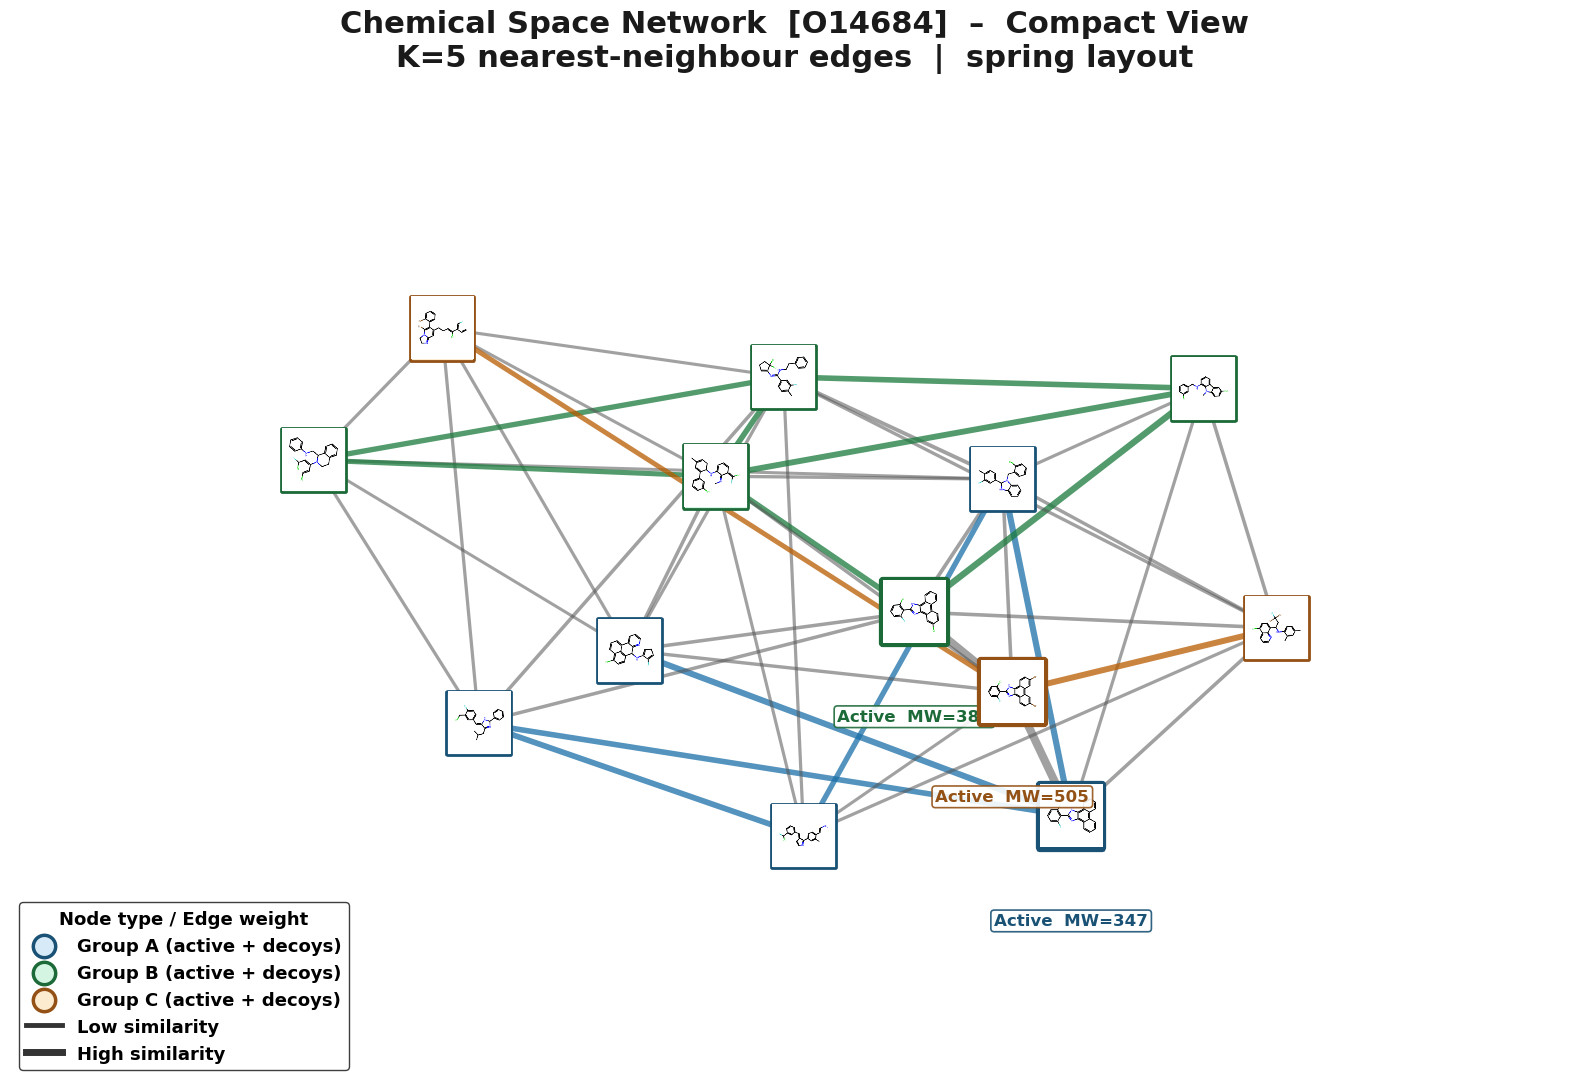

In [21]:
# ── CSN – compact / high-contrast view ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 11), facecolor='white')
ax2.set_facecolor('#EAEFF5')
ax2.axis('off')

# Dense edges: K=5
K2 = 5
G2 = nx.Graph()
for i in range(n):
    G2.add_node(i, node_type=df_nodes.loc[i,'type'], group=df_nodes.loc[i,'group'])
for i in range(n):
    top_k = np.argsort(sim[i])[::-1][1:K2+1]
    for j in top_k:
        G2.add_edge(i, j, weight=float(sim[i,j]))

# Spring layout seeded from manual positions
pos2 = nx.spring_layout(G2, pos=pos, seed=42, k=0.6, iterations=80, weight='weight')

# Darker, saturated group colours
EDGE_COLORS  = ['#1A6FA8', '#1A7A3C', '#B85C00']   # blue / green / orange
FACE_COLORS  = ['#D6EAF8', '#D5F5E3', '#FDEBD0']
BORDER_COLORS= ['#1A5276', '#1D6A39', '#935116']

# ── Edges ─────────────────────────────────────────────────────────────────────
for u, v, d in G2.edges(data=True):
    xu, yu = pos2[u]
    xv, yv = pos2[v]
    gu, gv = df_nodes.loc[u,'group'], df_nodes.loc[v,'group']
    if gu == gv:
        color = EDGE_COLORS[gu]
        lw    = 2.5 + d['weight'] * 10
        alpha = 0.75
    else:
        color = '#555555'
        lw    = 1.5 + d['weight'] * 6
        alpha = 0.55
    ax2.plot([xu, xv], [yu, yv], color=color,
             linewidth=lw, alpha=alpha, zorder=1, solid_capstyle='round')

# ── Nodes ─────────────────────────────────────────────────────────────────────
ZOOM2 = 0.30
for i, row in df_nodes.iterrows():
    mol = mols[i]
    if mol is None: continue
    g   = row['group']
    fc  = FACE_COLORS[g]
    ec  = BORDER_COLORS[g]
    lw  = 4.5 if row['type'] == 'Active' else 2.0
    img = mol_to_pil(mol, size=150)
    oi  = OffsetImage(np.array(img), zoom=ZOOM2)
    ab  = AnnotationBbox(oi, pos2[i], frameon=True, zorder=3,
                         bboxprops=dict(facecolor=fc, edgecolor=ec,
                                        linewidth=lw, boxstyle='round,pad=0.08'))
    ax2.add_artist(ab)
    if row['type'] == 'Active':
        ax2.text(pos2[i][0], pos2[i][1] - 0.24,
                 f'Active  MW={row["MW"]:.0f}',
                 ha='center', va='top',
                 fontsize=12, fontweight='bold', color=ec,
                 bbox=dict(facecolor='white', edgecolor=ec,
                           linewidth=1.2, boxstyle='round,pad=0.2', alpha=0.9))

# ── Legend ────────────────────────────────────────────────────────────────────
leg2 = []
for g, label in enumerate(['Group A', 'Group B', 'Group C']):
    leg2.append(plt.scatter([], [], s=260, facecolor=FACE_COLORS[g],
                            edgecolors=BORDER_COLORS[g], linewidths=2.5,
                            label=f'{label} (active + decoys)'))
for sv, sl in [(0.10, 'Low similarity'), (0.25, 'High similarity')]:
    leg2.append(ax2.plot([], [], color='#333333',
                         linewidth=2.5 + sv*10, label=sl)[0])
ax2.legend(handles=leg2, fontsize=13, loc='lower left', framealpha=0.95,
           edgecolor='#333', title='Node type / Edge weight',
           title_fontsize=13)

ax2.set_title(
    f'Chemical Space Network  [{target_id}]  –  Compact View\n'
    f'K={K2} nearest-neighbour edges  |  spring layout',
    fontsize=22, fontweight='bold', color='#1a1a1a', pad=14)

all_x = [p[0] for p in pos2.values()]
all_y = [p[1] for p in pos2.values()]
pad = 0.6
ax2.set_xlim(min(all_x)-pad, max(all_x)+pad)
ax2.set_ylim(min(all_y)-pad, max(all_y)+pad)

fig2.tight_layout()
save_fig(fig2, f'fig7b_csn_compact_{target_id}')
plt.show()

## Figure 2.1 – Chemical Space Network: Single Active + Decoys

[13:57:19] DEPRECATION WARNING: please use MorganGenerator
[13:57:19] DEPRECATION WARNING: please use MorganGenerator
[13:57:19] DEPRECATION WARNING: please use MorganGenerator
[13:57:19] DEPRECATION WARNING: please use MorganGenerator


Pairwise Tanimoto similarities:
  Active – Decoy1: 0.338
  Active – Decoy2: 0.325
  Active – Decoy3: 0.320
  Decoy1 – Decoy2: 0.280
  Decoy1 – Decoy3: 0.225
  Decoy2 – Decoy3: 0.265
Saved  fig2_1_csn_single_active  →  ../data/output/figures/diagram_components


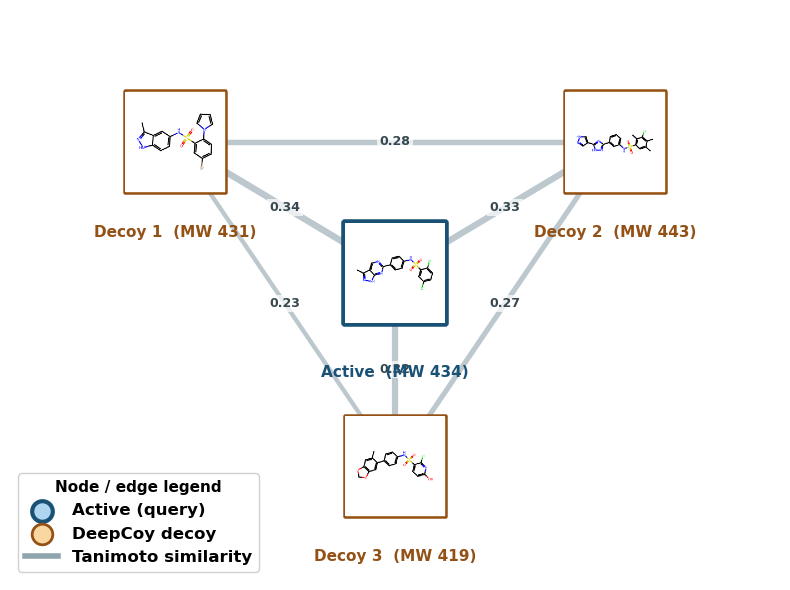

In [60]:
# ── Figure 2.1: CSN for a single query compound + 3 decoys ──────────────────
from rdkit import DataStructs
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

ACTIVE_SMI = 'Cc1n[nH]c2nc(-c3ccc(NS(=O)(=O)c4cc(Cl)ccc4Cl)cc3)ncc12'
DECOY_SMIS = [
    'Cc1n[nH]c2ccc(NS(=O)(=O)c3cc(Br)ccc3-n3cccc3)cc12',
    'Cc1cc(S(=O)(=O)Nc2cccc(-c3n[nH]c(-c4cn[nH]c4)n3)c2)c(C)c(Cl)c1C',
    'Cc1cc2c(cc1-c1ccc(NS(=O)(=O)c3ccc(O)nc3Cl)cc1)OCO2',
]

# ── Molecule objects & fingerprints ─────────────────────────────────────────
all_smis  = [ACTIVE_SMI] + DECOY_SMIS
all_types = ['Active'] + ['Decoy'] * len(DECOY_SMIS)
mols = [Chem.MolFromSmiles(s) for s in all_smis]
fps  = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) for m in mols]
n    = len(fps)

sim = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        v = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        sim[i, j] = sim[j, i] = v

print('Pairwise Tanimoto similarities:')
labels_short = ['Active', 'Decoy1', 'Decoy2', 'Decoy3']
for i in range(n):
    for j in range(i + 1, n):
        print(f'  {labels_short[i]} – {labels_short[j]}: {sim[i,j]:.3f}')

# ── Build graph (all edges with sim > 0) ────────────────────────────────────
G21 = nx.Graph()
for i in range(n):
    G21.add_node(i, node_type=all_types[i])
for i in range(n):
    for j in range(i + 1, n):
        if sim[i, j] > 0.0:
            G21.add_edge(i, j, weight=float(sim[i, j]))

# ── Manual layout: active centre, decoys around ──────────────────────────────
pos21 = {
    0: np.array([ 0.0,  0.0]),   # active – centre
    1: np.array([-2.0,  1.5]),   # decoy 1
    2: np.array([ 2.0,  1.5]),   # decoy 2
    3: np.array([ 0.0, -2.2]),   # decoy 3
}

# ── Colour scheme ──────────────────────────────────────────────────────────
ACTIVE_FC = '#AED6F1'
ACTIVE_EC = '#1A5276'
DECOY_FC  = '#FAD7A0'
DECOY_EC  = '#935116'

# ── mol → PIL image ─────────────────────────────────────────────────────────
def mol_to_pil(mol, size=180):
    d = rdMolDraw2D.MolDraw2DCairo(size, size)
    d.drawOptions().addStereoAnnotation = False
    d.drawOptions().padding = 0.12
    d.DrawMolecule(mol)
    d.FinishDrawing()
    return Image.open(BytesIO(d.GetDrawingText())).convert('RGBA')

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('#F7F9FC')
ax.axis('off')

# Edges
for u, v, d in G21.edges(data=True):
    xu, yu = pos21[u]
    xv, yv = pos21[v]
    ax.plot([xu, xv], [yu, yv],
            color='#90A4AE', linewidth=d['weight'] * 14,
            alpha=0.6, zorder=1, solid_capstyle='round')
    # Edge weight label at midpoint
    mx, my = (xu + xv) / 2, (yu + yv) / 2
    ax.text(mx, my, f'{d["weight"]:.2f}',
            ha='center', va='center', fontsize=9,
            color='#37474F', zorder=2,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1.5))

# Nodes
ZOOM = 0.40
for i, (smi, ntype) in enumerate(zip(all_smis, all_types)):
    mol = mols[i]
    fc  = ACTIVE_FC if ntype == 'Active' else DECOY_FC
    ec  = ACTIVE_EC if ntype == 'Active' else DECOY_EC
    lw  = 4.0 if ntype == 'Active' else 1.8
    img = mol_to_pil(mol)
    oi  = OffsetImage(np.array(img), zoom=ZOOM)
    ab  = AnnotationBbox(oi, pos21[i], frameon=True, zorder=3,
                         bboxprops=dict(facecolor=fc, edgecolor=ec,
                                        linewidth=lw, boxstyle='round,pad=0.10'))
    ax.add_artist(ab)
    # Node label below
    offset = -1.05 if ntype == 'Active' else -0.95
    tag = ntype if ntype == 'Active' else f'Decoy {i}'
    mw  = Descriptors.MolWt(mol)
    ax.text(pos21[i][0], pos21[i][1] + offset, f'{tag}  (MW {mw:.0f})',
            ha='center', va='top', fontsize=11, color=ec)

# Legend
legend_handles = [
    plt.scatter([], [], s=220, facecolor=ACTIVE_FC, edgecolors=ACTIVE_EC,
                linewidths=3, label='Active (query)'),
    plt.scatter([], [], s=220, facecolor=DECOY_FC, edgecolors=DECOY_EC,
                linewidths=2, label='DeepCoy decoy'),
    ax.plot([], [], color='#90A4AE', linewidth=4, label='Tanimoto similarity')[0],
]
ax.legend(handles=legend_handles, fontsize=12, loc='lower left',
          framealpha=0.92, title='Node / edge legend', title_fontsize=11)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.0)
fig.tight_layout()
save_fig(fig, 'fig2_1_csn_single_active')
plt.show()